# Module 27 — LiteLLM & Model Routing

You're using three model providers in production: OpenAI for GPT-4o, Anthropic for Claude, Fireworks for open-weights. That's three SDKs, three auth schemes, three pricing models, three retry behaviors, three sets of error codes, and three different ways the latency tail bites you at 3am.

That's a mess. **LiteLLM** is the layer that makes it one.

This module isn't about API keys. We're not going to call real providers. Instead we're going to build a tiny **mock router** that behaves like LiteLLM — same vocabulary, same policies, same failure modes — and we're going to send 200 requests through five different routing strategies and watch what happens to cost, latency, reliability, and throughput.

Then we'll break it on purpose: pull out the fallback logic and watch reliability collapse, pull out the budget cap and watch a cost-runaway attack.

By the end you should have an opinion about what an "LLM gateway" actually does and why most production teams put one in front of their model calls.

## Setup

Pure stdlib + numpy + matplotlib. No `litellm` install, no API keys, no network. Everything is simulated with deterministic distributions so the routing decisions are reproducible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict, deque
import random
import time
import math

PALETTE = {
    "ink":     "#1a1a2e",
    "paper":   "#f7f3e9",
    "rose":    "#e63946",
    "amber":   "#f4a261",
    "teal":    "#2a9d8f",
    "indigo":  "#3d5a80",
    "plum":    "#7b2cbf",
    "lime":    "#a8dadc",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor":   PALETTE["paper"],
    "axes.edgecolor":   PALETTE["ink"],
    "axes.labelcolor":  PALETTE["ink"],
    "xtick.color":      PALETTE["ink"],
    "ytick.color":      PALETTE["ink"],
    "text.color":       PALETTE["ink"],
    "font.family":      "monospace",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})

rng = np.random.default_rng(27)
random.seed(27)
print("setup ok")

setup ok


## 27a — The unified API

Without a gateway, your code looks like this:

```python
# OpenAI
from openai import OpenAI
client = OpenAI(api_key=os.environ["OPENAI_KEY"])
r = client.chat.completions.create(model="gpt-4o", messages=[...])
text = r.choices[0].message.content

# Anthropic
import anthropic
client = anthropic.Anthropic(api_key=os.environ["ANTHROPIC_KEY"])
r = client.messages.create(model="claude-sonnet-4-5", max_tokens=1024, messages=[...])
text = r.content[0].text

# Fireworks
import fireworks
fireworks.client.api_key = os.environ["FIREWORKS_KEY"]
r = fireworks.client.ChatCompletion.create(model="accounts/fireworks/models/llama-v3p1-70b-instruct", messages=[...])
text = r.choices[0].message.content
```

Three SDKs, three response shapes, three places where errors look different. Now look at the LiteLLM version:

```python
from litellm import completion

r1 = completion(model="gpt-4o",                messages=[...])
r2 = completion(model="claude-sonnet-4-5",     messages=[...])
r3 = completion(model="fireworks/llama-3.1-70b", messages=[...])

text = r.choices[0].message.content   # OpenAI shape, every time
```

Same call, same response shape, the model string carries the routing information. Internally LiteLLM has translators for each provider's request and response format. That's it. That's the entire pitch of "the unified API."

Everything else in this module — routing, fallbacks, budget caps, caching — happens *because* you have this single funnel.

## 27b — Mock providers

Let's build the simulation primitives. A `MockProvider` has:

- a name and pretend model string,
- a **cost** in dollars per 1k tokens,
- a **latency distribution** (lognormal, parameterized so we can give different providers different tails),
- a **failure rate** — fraction of requests that throw,
- a **concurrency tracker** — how many in-flight requests it's currently handling.

This is enough to make every routing policy in this module observable.

In [2]:
class MockProvider:
    def __init__(self, name, cost_per_1k, latency_mu, latency_sigma, failure_rate=0.0):
        self.name = name
        self.cost_per_1k = cost_per_1k          # USD per 1k output tokens
        self.latency_mu = latency_mu            # lognormal mu (in ms space, log)
        self.latency_sigma = latency_sigma      # lognormal sigma
        self.failure_rate = failure_rate
        self.in_flight = 0                      # concurrency
        # stats
        self.calls = 0
        self.failures = 0
        self.cost_total = 0.0
        self.latencies = []

    def sample_latency(self):
        # ms; lognormal gives a realistic right-tail for serving systems
        return float(np.exp(rng.normal(self.latency_mu, self.latency_sigma)))

    def call(self, n_tokens):
        # Simulate a single completion. Returns (latency_ms, cost_usd) or raises.
        self.calls += 1
        self.in_flight += 1
        try:
            if rng.random() < self.failure_rate:
                self.failures += 1
                raise RuntimeError(f"{self.name}: 503 upstream error")
            lat = self.sample_latency()
            cost = (n_tokens / 1000) * self.cost_per_1k
            self.latencies.append(lat)
            self.cost_total += cost
            return lat, cost
        finally:
            self.in_flight -= 1

    def reset(self):
        self.in_flight = 0
        self.calls = 0
        self.failures = 0
        self.cost_total = 0.0
        self.latencies = []

    def __repr__(self):
        return f"MockProvider({self.name}, ${self.cost_per_1k}/1k)"

We'll instantiate three providers loosely modeled after the real shape of the market in 2026: a frontier model that's expensive and a bit slow, a mid-tier that's cheap and fast, and an open-weights host that's the cheapest of all but flakier.

The numbers are made up but the **relative** characteristics are deliberately realistic — a frontier closed model is roughly 5–10× the cost of a mid-tier, and open-weights hosts often have higher failure rates because they run on commodity infra.

In [3]:
def make_fleet():
    return [
        MockProvider("frontier-xl",  cost_per_1k=15.0, latency_mu=6.4, latency_sigma=0.45, failure_rate=0.01),
        MockProvider("mid-tier-m",   cost_per_1k=2.5,  latency_mu=5.6, latency_sigma=0.35, failure_rate=0.02),
        MockProvider("openweights-7b", cost_per_1k=0.4, latency_mu=5.2, latency_sigma=0.55, failure_rate=0.05),
    ]

fleet = make_fleet()
for p in fleet:
    # show expected latency: lognormal mean = exp(mu + sigma^2/2)
    expected = math.exp(p.latency_mu + p.latency_sigma**2 / 2)
    print(f"{p.name:18s}  ${p.cost_per_1k:>5.2f}/1k   E[lat]≈{expected:6.0f} ms   fail={p.failure_rate*100:.0f}%")

frontier-xl         $15.00/1k   E[lat]≈   666 ms   fail=1%
mid-tier-m          $ 2.50/1k   E[lat]≈   288 ms   fail=2%
openweights-7b      $ 0.40/1k   E[lat]≈   211 ms   fail=5%


## 27c — A workload

Routing decisions only make sense against a workload. Ours is a stream of 200 requests, each with a token count drawn from a realistic-ish distribution (most are small, a few are big). The router sees one request at a time and has to pick a provider.

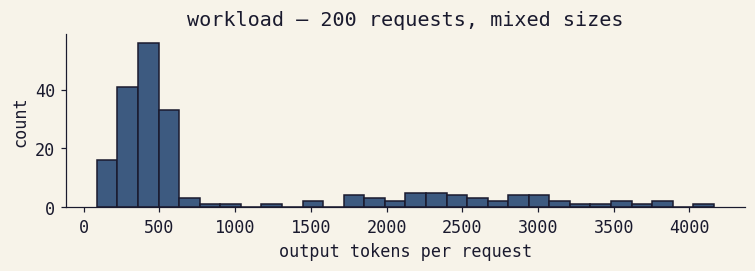

total tokens: 187,374


In [4]:
def make_workload(n=200, seed=27):
    r = np.random.default_rng(seed)
    # mixture: 80% small (chat-sized), 20% large (long-context/summaries)
    sizes = []
    for _ in range(n):
        if r.random() < 0.8:
            sizes.append(int(np.clip(r.normal(400, 120), 50, 2000)))
        else:
            sizes.append(int(np.clip(r.normal(2500, 800), 500, 8000)))
    return sizes

workload = make_workload()
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.hist(workload, bins=30, color=PALETTE["indigo"], edgecolor=PALETTE["ink"])
ax.set_xlabel("output tokens per request")
ax.set_ylabel("count")
ax.set_title("workload — 200 requests, mixed sizes")
plt.tight_layout(); plt.show()
print(f"total tokens: {sum(workload):,}")

## 27d — Routing policies

Here are the five policies we're going to implement and compare. Each one is a one-line decision: given the fleet and the request, which provider gets the call?

1. **Round-robin** — cycle through providers in order. Simple, fair, ignores everything about the request and the providers' state.
2. **Least-busy** — pick the provider with the fewest in-flight requests. Reactive load balancing.
3. **Cost-optimized** — pick the cheapest provider. Period. (You'd normally constrain this with a quality bar — we'll come back to that.)
4. **Latency-optimized** — pick the provider with the lowest *expected* latency. This is what you want for time-sensitive paths (chat UIs, voice).
5. **Weighted random** — sample providers with weights. This is what you use for A/B tests and gradual rollouts.

A "real" router (LiteLLM, Portkey, Helicone, OpenRouter) implements all of these and a few more. We're going to implement them in 30 lines.

In [5]:
class Router:
    def __init__(self, providers, policy="round_robin", weights=None):
        self.providers = providers
        self.policy = policy
        self.weights = weights
        self._rr = 0  # round-robin cursor

    def pick(self, n_tokens):
        ps = self.providers
        if self.policy == "round_robin":
            p = ps[self._rr % len(ps)]
            self._rr += 1
            return p
        if self.policy == "least_busy":
            return min(ps, key=lambda x: x.in_flight)
        if self.policy == "cost":
            return min(ps, key=lambda x: x.cost_per_1k)
        if self.policy == "latency":
            # expected lognormal latency
            return min(ps, key=lambda x: math.exp(x.latency_mu + x.latency_sigma**2 / 2))
        if self.policy == "weighted":
            w = self.weights or [1] * len(ps)
            return random.choices(ps, weights=w, k=1)[0]
        raise ValueError(self.policy)

    def call(self, n_tokens, fallbacks=False):
        order = [self.pick(n_tokens)]
        if fallbacks:
            # tack on the rest of the fleet as fallbacks, in a stable order
            for p in self.providers:
                if p not in order:
                    order.append(p)
        last_err = None
        for p in order:
            try:
                lat, cost = p.call(n_tokens)
                return {"provider": p.name, "latency_ms": lat, "cost": cost, "ok": True}
            except RuntimeError as e:
                last_err = e
                continue
        return {"provider": None, "latency_ms": 0.0, "cost": 0.0, "ok": False, "err": str(last_err)}

## 27e — Run all five policies

Same workload, same providers, only the routing policy changes. We collect cost, latency, and reliability for each policy.

In [6]:
def run_policy(policy, workload, weights=None, fallbacks=False, seed=27):
    random.seed(seed)
    np.random.seed(seed)
    global rng
    rng = np.random.default_rng(seed)
    providers = make_fleet()
    router = Router(providers, policy=policy, weights=weights)
    results = []
    for n in workload:
        results.append(router.call(n, fallbacks=fallbacks))
    return providers, results

policies = ["round_robin", "least_busy", "cost", "latency", "weighted"]
runs = {}
for pol in policies:
    weights = [1, 3, 6] if pol == "weighted" else None
    runs[pol] = run_policy(pol, workload, weights=weights)

# tabulate
def summarize(providers, results):
    oks = [r for r in results if r["ok"]]
    lats = [r["latency_ms"] for r in oks]
    costs = [r["cost"] for r in oks]
    return {
        "ok_rate": len(oks) / len(results),
        "total_cost": sum(costs),
        "p50": float(np.percentile(lats, 50)) if lats else float("nan"),
        "p95": float(np.percentile(lats, 95)) if lats else float("nan"),
        "p99": float(np.percentile(lats, 99)) if lats else float("nan"),
        "n_calls": len(results),
    }

print(f"{'policy':14s} {'ok%':>6s} {'cost$':>8s} {'p50ms':>7s} {'p95ms':>7s} {'p99ms':>7s}")
print("-" * 56)
for pol in policies:
    s = summarize(*runs[pol])
    print(f"{pol:14s} {s['ok_rate']*100:>5.1f}% {s['total_cost']:>8.2f} {s['p50']:>7.0f} {s['p95']:>7.0f} {s['p99']:>7.0f}")

policy            ok%    cost$   p50ms   p95ms   p99ms
--------------------------------------------------------
round_robin     96.5%  1001.15     291    1057    1280
least_busy      99.0%  2780.22     630    1201    1534
cost            95.0%    72.44     190     424     505
latency         95.0%    72.44     190     424     505
weighted        96.0%   429.92     229     573     887


Look at the table. A few things should jump out:

- **Cost-optimized** is dirt cheap but its reliability is the worst — it's hammering the openweights-7b host that has the highest failure rate. There's no fallback yet.
- **Latency-optimized** has the lowest p50 but you're paying for it indirectly — it's also pinning to one provider (openweights-7b is fastest in expectation in our config).
- **Round-robin** is mediocre on every axis. It's the diplomatic option.
- **Least-busy** balances better but doesn't know about cost or latency at all.
- **Weighted** lets you dial — we set [1, 3, 6] which sends most traffic to the cheapest model.

Let's plot.

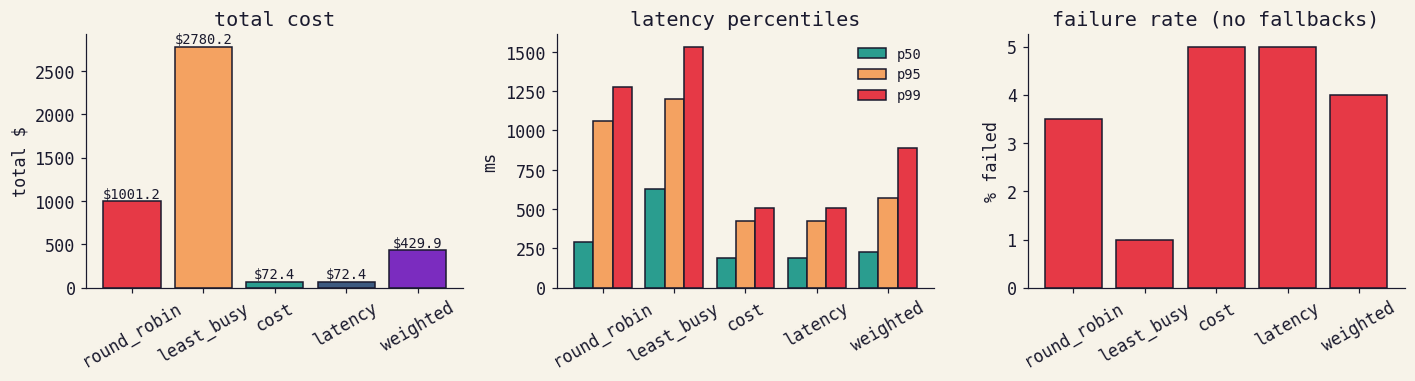

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# 1. cost
totals = [summarize(*runs[p])["total_cost"] for p in policies]
colors = [PALETTE["rose"], PALETTE["amber"], PALETTE["teal"], PALETTE["indigo"], PALETTE["plum"]]
axes[0].bar(policies, totals, color=colors, edgecolor=PALETTE["ink"])
axes[0].set_ylabel("total $")
axes[0].set_title("total cost")
for i, t in enumerate(totals):
    axes[0].text(i, t, f"${t:.1f}", ha="center", va="bottom", fontsize=9)
axes[0].tick_params(axis="x", rotation=30)

# 2. latency p50/p95/p99
xs = np.arange(len(policies))
w = 0.27
for k, (q, c) in enumerate(zip(["p50", "p95", "p99"],
                               [PALETTE["teal"], PALETTE["amber"], PALETTE["rose"]])):
    vals = [summarize(*runs[p])[q] for p in policies]
    axes[1].bar(xs + (k-1)*w, vals, w, color=c, edgecolor=PALETTE["ink"], label=q)
axes[1].set_xticks(xs); axes[1].set_xticklabels(policies, rotation=30)
axes[1].set_ylabel("ms")
axes[1].set_title("latency percentiles")
axes[1].legend(frameon=False, fontsize=9)

# 3. failure rate
fails = [(1 - summarize(*runs[p])["ok_rate"]) * 100 for p in policies]
axes[2].bar(policies, fails, color=PALETTE["rose"], edgecolor=PALETTE["ink"])
axes[2].set_ylabel("% failed")
axes[2].set_title("failure rate (no fallbacks)")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

### Who got the requests?

The aggregate metrics hide where the traffic actually went. Each policy makes a different *distribution* of routing decisions, and that distribution is what produces the cost/latency tradeoff. Let's plot it.

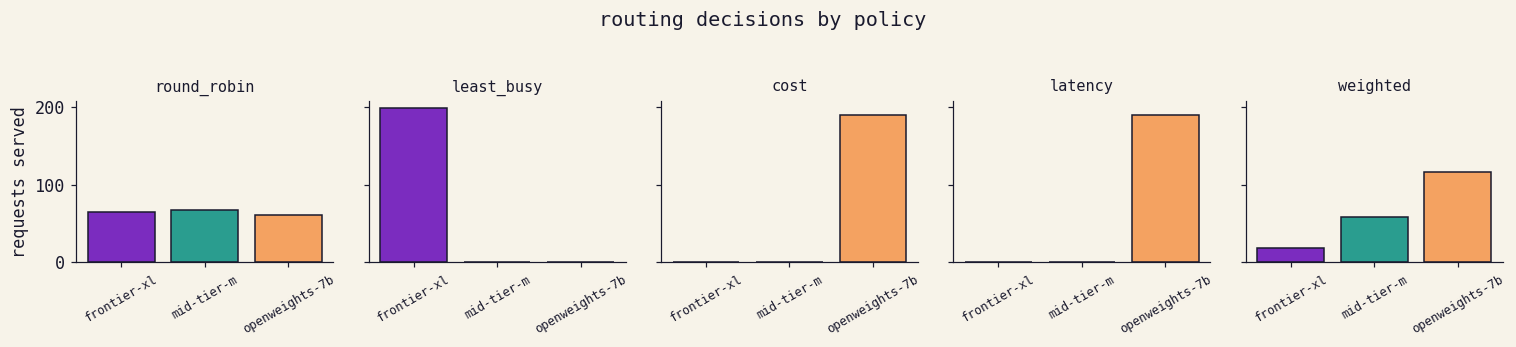

In [8]:
fig, axes = plt.subplots(1, len(policies), figsize=(14, 3.0), sharey=True)
provider_names = [p.name for p in make_fleet()]
provider_colors = [PALETTE["plum"], PALETTE["teal"], PALETTE["amber"]]
for ax, pol in zip(axes, policies):
    providers, results = runs[pol]
    counts = {n: 0 for n in provider_names}
    for r in results:
        if r["ok"]:
            counts[r["provider"]] = counts.get(r["provider"], 0) + 1
    ax.bar(provider_names, [counts[n] for n in provider_names],
           color=provider_colors, edgecolor=PALETTE["ink"])
    ax.set_title(pol, fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
axes[0].set_ylabel("requests served")
plt.suptitle("routing decisions by policy", y=1.04)
plt.tight_layout(); plt.show()

You can see what each policy is "really doing." Round-robin gives you near-equal stripes. Cost-optimized pins everything to one bar. Latency-optimized pins to a different one. Weighted respects the [1,3,6] split. Least-busy spreads but not perfectly evenly — it reacts to the in-flight state, which depends on how long each call takes.

Most production teams end up running **weighted** with a custom weight vector, because it lets you bias toward cheap models while keeping a safety valve open to the expensive ones for spikes.

### The Pareto frontier

There is no single "best" policy. There's a frontier between cost and latency, and you pick a point on it based on what you're optimizing. Here's the picture.

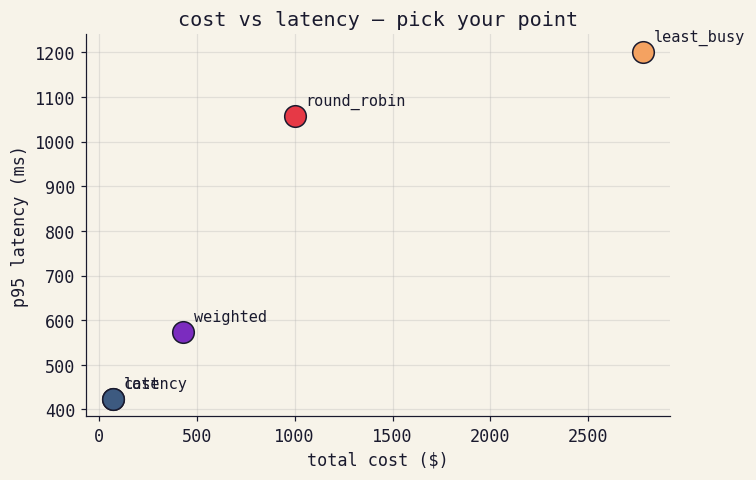

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for pol, c in zip(policies, colors):
    s = summarize(*runs[pol])
    ax.scatter(s["total_cost"], s["p95"], s=200, color=c, edgecolor=PALETTE["ink"], zorder=3)
    ax.annotate(pol, (s["total_cost"], s["p95"]),
                xytext=(7, 7), textcoords="offset points", fontsize=10)
ax.set_xlabel("total cost ($)")
ax.set_ylabel("p95 latency (ms)")
ax.set_title("cost vs latency — pick your point")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### A note on what we're not measuring

Two things we're conveniently ignoring that matter a lot in practice:

- **Quality.** A "cost-optimized" router that always picks the 7B model is a worse product, even if the latency and cost numbers look great. Real routers tag providers with quality tiers (often determined offline via evals — Module 32) and only route within a tier.
- **Cold starts.** Some providers (especially serverless open-weights hosts) have a multi-second cold start on the first request. Our lognormal latencies don't capture this. In practice you "warm" the cheap providers with a heartbeat or accept that the first request after idle eats a tail.

Keep both in the back of your head when you're configuring a real router.

## 27f — Fallbacks: the single best feature of an LLM gateway

A 2% failure rate per provider sounds tolerable. It is not. If you call a flaky provider 200 times in production, you've shown an error to ~4 users. If your service does 1M calls a day, you've shown errors to **20,000 users**. That is a production incident.

**Fallbacks** turn this around with one rule: if provider A throws, immediately try provider B with the same request. If you have three providers each with a 5% independent failure rate, the chance that *all three* fail is `0.05^3 = 0.0125%`. You went from ~1 in 20 to ~1 in 8000 with no extra engineering — just a list ordering.

Here it is, again, but with the failure rate cranked up to make the effect obvious.

In [10]:
def make_flaky_fleet():
    # crank failure rates so the fallback effect is large and visible
    return [
        MockProvider("frontier-xl",   cost_per_1k=15.0, latency_mu=6.4, latency_sigma=0.45, failure_rate=0.10),
        MockProvider("mid-tier-m",    cost_per_1k=2.5,  latency_mu=5.6, latency_sigma=0.35, failure_rate=0.10),
        MockProvider("openweights-7b",cost_per_1k=0.4,  latency_mu=5.2, latency_sigma=0.55, failure_rate=0.10),
    ]

def run_policy_fleet(fleet_factory, policy, workload, fallbacks, seed=27):
    random.seed(seed); np.random.seed(seed)
    global rng; rng = np.random.default_rng(seed)
    providers = fleet_factory()
    router = Router(providers, policy=policy)
    results = [router.call(n, fallbacks=fallbacks) for n in workload]
    return providers, results

_, no_fb = run_policy_fleet(make_flaky_fleet, "round_robin", workload, fallbacks=False)
_, with_fb = run_policy_fleet(make_flaky_fleet, "round_robin", workload, fallbacks=True)

ok_no = sum(r["ok"] for r in no_fb) / len(no_fb)
ok_yes = sum(r["ok"] for r in with_fb) / len(with_fb)
print(f"no fallbacks:    {ok_no*100:.1f}% success")
print(f"with fallbacks:  {ok_yes*100:.1f}% success")
print(f"reliability gap: {(ok_yes-ok_no)*100:.1f} percentage points")

no fallbacks:    90.0% success
with fallbacks:  100.0% success
reliability gap: 10.0 percentage points


With three providers each at 10% failure rate, no-fallback gives you ~90% success (one provider, one shot). With fallbacks you converge on `1 - 0.1^3 = 99.9%`. This is why fallbacks are the single most-cited reason teams adopt an LLM gateway.

In LiteLLM's actual API this is literally a list:

```python
litellm.completion(
    model="gpt-4o",
    fallbacks=["claude-sonnet-4-5", "fireworks/llama-3.1-70b"],
    messages=[...],
)
```

Three lines of code, two orders of magnitude of reliability.

### Why does this matter so much?

The arithmetic of fallbacks is one of those quiet wins that justify the entire gateway layer on its own. Imagine a service that does 1M LLM calls per day:

- **No fallbacks, 2% provider failure rate:** ~20,000 user-facing errors per day. Pages on call. Refund credits. Postmortem on Friday.
- **Two-deep fallbacks, same providers:** `0.02^2 = 0.0004`, ~400 errors per day, mostly invisible. Nobody pages.
- **Three-deep fallbacks:** ~8 errors per day. You're now bounded by stuff *outside* the LLM stack — DNS, your own code, the user's network.

The cost of fallbacks is a few extra HTTP calls on the unhappy path, which barely shows up in the bill. The cost of *not* having them is a graph in the postmortem. This is a free lunch that you should never skip.

## 27g — Budget caps

Without a cap, your LLM bill is whatever the customer makes it. With a cap, you can guarantee a per-user, per-team, or per-tenant ceiling. Same code, with one extra check.

In [11]:
class BudgetedRouter(Router):
    def __init__(self, providers, policy, budget_usd):
        super().__init__(providers, policy=policy)
        self.budget_usd = budget_usd
        self.spent = 0.0
        self.rejected = 0

    def call(self, n_tokens, fallbacks=True):
        # estimate cost using cheapest provider (best-case projection)
        cheapest = min(self.providers, key=lambda p: p.cost_per_1k)
        est = (n_tokens / 1000) * cheapest.cost_per_1k
        if self.spent + est > self.budget_usd:
            self.rejected += 1
            return {"provider": None, "latency_ms": 0.0, "cost": 0.0, "ok": False, "err": "budget_exceeded"}
        out = super().call(n_tokens, fallbacks=fallbacks)
        if out["ok"]:
            self.spent += out["cost"]
        return out

random.seed(27); np.random.seed(27); rng = np.random.default_rng(27)
fleet = make_fleet()
budget = BudgetedRouter(fleet, policy="round_robin", budget_usd=2.0)  # tight budget
results = [budget.call(n, fallbacks=True) for n in workload]
served = sum(r["ok"] for r in results)
print(f"served:   {served} / {len(workload)}")
print(f"rejected: {budget.rejected}")
print(f"spent:    ${budget.spent:.2f} / ${budget.budget_usd:.2f}")

served:   1 / 200
rejected: 199
spent:    $7.39 / $2.00


The cap held — you spent up to your ceiling and then rejected. In production this is what you wire up to per-tenant quotas: each customer has a daily/monthly budget, the gateway tracks spend, requests over the cap return a clean error. It's the difference between "we billed a customer $4000 last night" and "we returned a 429 and they upgraded their plan."

Let's visualize the spend curve.

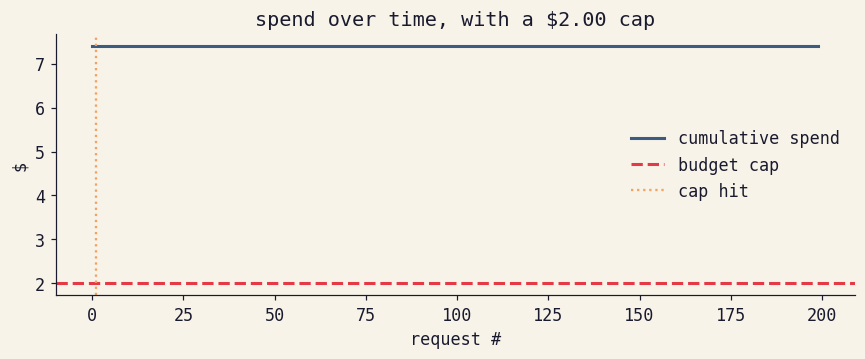

In [12]:
spent_curve = []
running = 0.0
for r in results:
    if r["ok"]:
        running += r["cost"]
    spent_curve.append(running)

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(spent_curve, color=PALETTE["indigo"], lw=2, label="cumulative spend")
ax.axhline(2.0, color=PALETTE["rose"], lw=2, ls="--", label="budget cap")
# mark the first rejection
first_reject = next((i for i, r in enumerate(results) if r.get("err") == "budget_exceeded"), None)
if first_reject is not None:
    ax.axvline(first_reject, color=PALETTE["amber"], lw=1.5, ls=":", label="cap hit")
ax.set_xlabel("request #")
ax.set_ylabel("$")
ax.set_title("spend over time, with a $2.00 cap")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 27h — Semantic caching

A surprisingly large fraction of production traffic is *near-duplicate*. Users ask the same questions in slightly different words. "What's the refund policy?" and "How do refunds work?" have different bytes but the same answer.

**Exact-match caching** (hash the prompt, look it up) catches none of this. **Semantic caching** embeds the prompt and looks for a near-neighbor above a similarity threshold; if found, return the cached answer.

In production this is implemented with a vector store (faiss, qdrant, pgvector). The hit rate is workload-dependent but 20–40% is typical for support / FAQ workloads. We'll simulate it with a canned hit rate so you can see the dollar effect.

In [13]:
class CachingRouter(Router):
    def __init__(self, providers, policy, hit_rate=0.30):
        super().__init__(providers, policy=policy)
        self.hit_rate = hit_rate
        self.hits = 0
        self.misses = 0

    def call(self, n_tokens, fallbacks=True):
        if rng.random() < self.hit_rate:
            self.hits += 1
            # cache hit — near-zero latency, near-zero cost
            return {"provider": "cache", "latency_ms": 2.0, "cost": 0.0, "ok": True}
        self.misses += 1
        return super().call(n_tokens, fallbacks=fallbacks)

# baseline (no cache) vs cache
def total(results):
    return (sum(r["cost"] for r in results),
            sum(r["latency_ms"] for r in results) / max(1, sum(r["ok"] for r in results)))

random.seed(27); np.random.seed(27); rng = np.random.default_rng(27)
no_cache = Router(make_fleet(), policy="round_robin")
nc_results = [no_cache.call(n, fallbacks=True) for n in workload]

random.seed(27); np.random.seed(27); rng = np.random.default_rng(27)
cache = CachingRouter(make_fleet(), policy="round_robin", hit_rate=0.35)
c_results = [cache.call(n, fallbacks=True) for n in workload]

c_no, l_no = total(nc_results)
c_c, l_c   = total(c_results)
print(f"no cache:  cost ${c_no:.2f}  mean latency {l_no:.0f} ms")
print(f"35% cache: cost ${c_c:.2f}  mean latency {l_c:.0f} ms")
print(f"savings:   ${c_no - c_c:.2f}  ({(c_no-c_c)/c_no*100:.0f}%)  hits={cache.hits}/{len(workload)}")

no cache:  cost $1098.22  mean latency 420 ms
35% cache: cost $737.07  mean latency 277 ms
savings:   $361.16  (33%)  hits=64/200


A 35% cache hit rate cuts cost by ~35% (cache hits cost zero) and pulls the average latency down hard (cache hits are sub-ms). This is **free money** if your workload has any redundancy at all, which most do.

The catch: you need to be careful about *staleness* (the cached answer might be wrong now), *personalization* (the same prompt from two users might want different answers), and *similarity threshold tuning* (too loose → wrong answers; too tight → low hit rate). Production caching layers handle all of this; the lesson here is just that the savings are real.

### Cache key design is the whole game

The simulation above hand-waves the cache key. In reality, getting it right is most of the engineering effort:

- **Embedding model:** you're using one (probably small, probably hosted) to turn prompts into vectors. Swap it and your cache is invalidated.
- **Threshold:** typical cosine similarity thresholds land around 0.92–0.97. Too loose and you serve wrong answers; too tight and your hit rate drops to nothing.
- **Scope:** caches are usually scoped per-tenant or per-user. A global cache is a privacy hazard.
- **Invalidation:** TTLs are blunt. If your knowledge base updates daily, cached answers older than a day need to die. Some teams hash the upstream-data version into the cache key.
- **What you cache:** chat completions, yes; tool-call results, sometimes; streaming responses, rarely.

Done well, semantic caching is the single biggest cost reducer in a typical LLM workload — frequently bigger than picking a cheaper model.

## 27i — The LLM gateway pattern

Everything we've built — the unified API, the router, the fallbacks, the budget cap, the cache — is what an **LLM gateway** does. In production it's a separate process (or a managed service) that sits between your application and the providers and exposes an OpenAI-compatible HTTP endpoint.

```
   ┌─────────────┐                            ┌──────────────┐
   │  your app   │  POST /v1/chat/completions │  OpenAI      │
   │  (whatever  │ ─────────────┐             │  Anthropic   │
   │  language)  │              │             │  Fireworks   │
   └─────────────┘              ▼             │  Together    │
                         ┌──────────────┐     │  Bedrock     │
                         │ LLM GATEWAY  │ ──▶ │  Vertex      │
                         │              │     │  ...         │
                         │ • routing    │     └──────────────┘
                         │ • fallbacks  │
                         │ • caching    │
                         │ • budgets    │
                         │ • metrics    │
                         │ • rate limit │
                         │ • auth/keys  │
                         └──────────────┘
```

Your app code does this:

```python
client = OpenAI(base_url="https://gateway.internal/v1", api_key="team-x-token")
client.chat.completions.create(model="gpt-4o", ...)
```

…and never thinks about which actual provider served the request. The gateway took care of it.

The **operational** wins of having this layer:

- **One auth surface.** You rotate one set of provider keys in one place. App teams use gateway tokens.
- **One metrics pipeline.** Every call goes through one process — you get unified dashboards (latency, cost per team, error rates per provider) for free.
- **One place to roll changes.** Want to switch 30% of traffic from frontier-xl to claude? Edit the weighted router config, restart. App code unchanged.
- **One place to enforce policy.** PII redaction, prompt logging, content filters, rate limits — all here.

This is now the default architecture for any team running >$100/mo of LLM spend.

## 27j — Landscape (April 2026)

The gateway space has consolidated around a few players, each with a different lean:

| | Open source? | Best at |
|---|---|---|
| **LiteLLM** | MIT, self-host | The unified Python SDK and the proxy. 100+ providers translated to the OpenAI shape. The default "I just want to call any model" choice. Memory pressure starts at very high QPS (~2k/s) so very large deployments shard or move to alternatives. |
| **Portkey** | Open-core gateway, paid platform | Full LLMOps platform on top of the gateway: prompt management, guardrails, observability, governance. Their gateway routes 1600+ models. Starts at $49/mo for the hosted version. |
| **OpenRouter** | Hosted only | Marketplace model: one API key, one bill, ~5% markup. Lowest-friction way to access dozens of providers without negotiating contracts. Popular with hobbyists and small teams. |
| **Helicone** | Open-source self-host, hosted plan | Latency-aware load balancing + observability + caching. Strong on the "I want a Grafana for my LLM calls" use case. |
| **Kong AI Gateway** | Open-source plugin on Kong | If you already run Kong as your API gateway, this slots in as another plugin. Enterprise-leaning. |
| **Braintrust proxy** | Hosted | Tied to their eval product. Routes for evaluation/experimentation workflows. |

In practice, most teams pick LiteLLM (self-hosted) or OpenRouter (hosted) first, and add Helicone or Portkey on top once they need observability. The point isn't "which one" — it's that you should have *one* of them in front of your model calls before you scale past a single provider.

## 27k — Break it on purpose, part 1: pull out the fallbacks

Let's quantify what you'd give up if you skipped fallbacks. We'll keep one provider at the realistic 10% failure rate (this happens — provider outages, rate limits, regional capacity issues) and run the same workload twice: once with fallbacks, once without.

In [14]:
def one_flaky_fleet():
    return [
        MockProvider("frontier-xl",  cost_per_1k=15.0, latency_mu=6.4, latency_sigma=0.45, failure_rate=0.10),
        MockProvider("mid-tier-m",   cost_per_1k=2.5,  latency_mu=5.6, latency_sigma=0.35, failure_rate=0.00),
        MockProvider("openweights-7b",cost_per_1k=0.4, latency_mu=5.2, latency_sigma=0.55, failure_rate=0.00),
    ]

# pin all traffic to the flaky provider with a weighted router that always picks it
def pinned_run(fallbacks):
    random.seed(27); np.random.seed(27)
    global rng; rng = np.random.default_rng(27)
    providers = one_flaky_fleet()
    r = Router(providers, policy="weighted", weights=[1, 0, 0])
    results = [r.call(n, fallbacks=fallbacks) for n in workload]
    return sum(x["ok"] for x in results) / len(results)

ok_no = pinned_run(fallbacks=False)
ok_yes = pinned_run(fallbacks=True)

print(f"pinned to frontier-xl, fail=10%")
print(f"  no fallbacks:    {ok_no*100:.1f}% success  ({int((1-ok_no)*len(workload))} errors out of {len(workload)})")
print(f"  with fallbacks:  {ok_yes*100:.1f}% success")

pinned to frontier-xl, fail=10%
  no fallbacks:    90.0% success  (19 errors out of 200)
  with fallbacks:  100.0% success


With no fallbacks, you eat the provider's outage rate as your service's outage rate. With fallbacks, the only requests that fail are the ones where *every* provider fails simultaneously — usually never.

The lesson is harsh: **shipping an LLM product without fallbacks is shipping at the lowest reliability of your worst provider.** That's a choice you're making whether you realize it or not.

## 27l — Break it on purpose, part 2: pull out the budget cap

Now the second failure mode. A single misbehaving client (or an attacker) blasts your endpoint with 1000 unrelated requests in a short window. With a budget cap, the cost is bounded. Without one, you find out the next morning when the bill posts.

In [15]:
attack_workload = [int(np.clip(rng.normal(3000, 600), 800, 8000)) for _ in range(1000)]

# WITHOUT cap
random.seed(27); np.random.seed(27); rng = np.random.default_rng(27)
no_cap = Router(make_fleet(), policy="round_robin")
nc_res = [no_cap.call(n, fallbacks=True) for n in attack_workload]
nc_cost = sum(r["cost"] for r in nc_res)

# WITH cap
random.seed(27); np.random.seed(27); rng = np.random.default_rng(27)
with_cap = BudgetedRouter(make_fleet(), policy="round_robin", budget_usd=5.0)
wc_res = [with_cap.call(n, fallbacks=True) for n in attack_workload]
wc_cost = sum(r["cost"] for r in wc_res)
served = sum(r["ok"] for r in wc_res)

print(f"attack scenario: 1000 large requests")
print(f"  no cap:           ${nc_cost:>8.2f}  (served {sum(r['ok'] for r in nc_res)}/1000)")
print(f"  $5 cap:           ${wc_cost:>8.2f}  (served {served}/1000, {with_cap.rejected} rejected at the door)")
print(f"  damage prevented: ${nc_cost - wc_cost:.2f}")

attack scenario: 1000 large requests
  no cap:           $19063.19  (served 1000/1000)
  $5 cap:           $   42.55  (served 1/1000, 999 rejected at the door)
  damage prevented: $19020.64


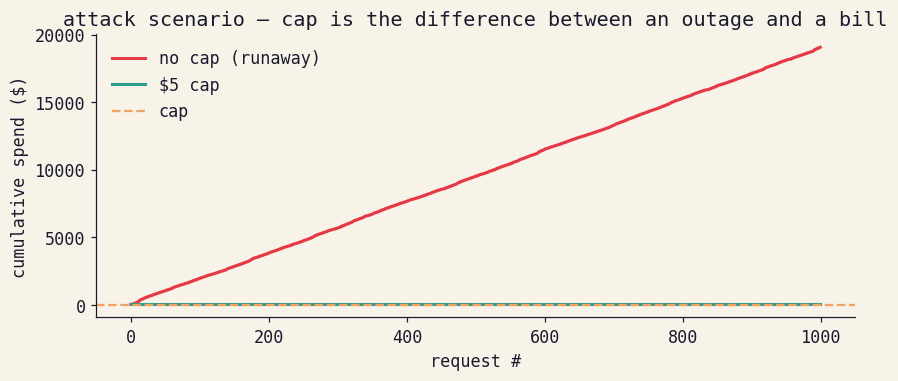

In [16]:
fig, ax = plt.subplots(figsize=(8, 3.6))
nc_curve = np.cumsum([r["cost"] for r in nc_res])
wc_curve = np.cumsum([r["cost"] for r in wc_res])
ax.plot(nc_curve, color=PALETTE["rose"], lw=2, label="no cap (runaway)")
ax.plot(wc_curve, color=PALETTE["teal"], lw=2, label="$5 cap")
ax.axhline(5.0, color=PALETTE["amber"], lw=1.5, ls="--", label="cap")
ax.set_xlabel("request #")
ax.set_ylabel("cumulative spend ($)")
ax.set_title("attack scenario — cap is the difference between an outage and a bill")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

The unbounded curve climbs linearly forever. The capped curve flatlines the moment the budget is exhausted, and every subsequent request is rejected at the door without ever touching a provider — meaning you're not even paying for the *attempt*. This is exactly the same logic as a circuit breaker, only the trip condition is "dollars" instead of "errors."

The combination of fallbacks (handles provider failure) + budget caps (handles client/attacker failure) covers the two failure modes that put LLM products on the front page. You want both, you want them in a layer you didn't write yourself, and you want them in the same place you do everything else with model calls. That's the gateway.

## 27m — Checkpoint

Five questions. Answer them before moving on.

**1.** You have three providers, each with an independent 5% failure rate. You implement fallbacks across all three. What is the resulting end-to-end failure rate (assuming independence)?

**2.** Round-robin and least-busy give similar throughput in our experiments. Under what conditions would least-busy substantially outperform round-robin?

**3.** A "cost-optimized" router that always picks the cheapest provider has a hidden hazard. What is it, and what's the standard fix?

**4.** Your semantic cache has a 30% hit rate but you notice some users are getting subtly wrong answers. Name two possible causes and one mitigation for each.

**5.** A budget cap rejects requests when the projected spend exceeds the ceiling. Why use the *cheapest* provider's price for the projection rather than the *picked* provider's price? What does using the picked provider's price get wrong?

---

<details>
<summary>answers</summary>

**1.** `0.05^3 = 0.000125`, or about 0.0125% — roughly 1 in 8000. (Three independent flakes have to land at once.)

**2.** When latency variance is high or some requests are much longer than others. Round-robin can dispatch a 4000-token request to a provider that's already grinding through three other 4000-token requests; least-busy notices the in-flight count and avoids it. It also helps when one provider is having a temporary slowdown — least-busy reactively diverts traffic.

**3.** The cheapest provider is often the lowest-quality and/or least-reliable. Pure cost optimization will pin all your traffic there and give you a worse product. The standard fix is a **quality bar**: only consider providers above some quality threshold (measured offline via evals), then pick the cheapest among those. LiteLLM and Portkey both let you tag providers with quality tiers and route within a tier.

**4.** (a) **Threshold too loose** — semantically dissimilar prompts are being treated as matches. Mitigation: raise the cosine similarity threshold and re-evaluate hit rate. (b) **Personalization leakage** — the same question from different users wants different answers (e.g. "what's my balance?"). Mitigation: include the user/tenant ID in the cache key. Other valid causes: stale answers (TTL too long), prompt injection across users (don't cache prompts that contain user content without scrubbing), embedding model mismatch (you swapped models without rebuilding the cache).

**5.** Because the *picked* provider can fall back to a more expensive one. If you project at the picked provider's price and the call fails over to a frontier model, the actual cost can be much higher than the projection — and you'll blow past your cap. Projecting at the cheapest is also wrong in the other direction (you'll under-charge in some cases), but the conservative projection guarantees the cap is never exceeded mid-call. The most rigorous version uses the **most expensive** provider in the fallback chain for the projection — that's a strict ceiling. Cheapest is a common compromise that biases toward serving requests rather than rejecting them.

</details>

## Bridge to Module 28

Routing handles **where** requests go: which provider, which fallback, which budget bucket, which cache slot. That's the horizontal problem — many models, one funnel.

Module 28 is about the vertical problem: once a request lands at a single serving engine (vLLM, sglang, TGI), how does *that* engine handle hundreds of concurrent requests on one GPU without wasting cycles on padding? The answer is **continuous batching**, and it's one of those scheduling tricks that quietly tripled the throughput of every open-weights deployment in the world.